In [1]:
#import various packages for running code

import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Input, Activation, BatchNormalization,Dropout
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
import keras
from tensorflow.keras import layers, models

2025-03-28 15:40:31.390952: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#import the data in ready-to-use arrays obtained from sort_data.py

#testing data
file_path = '../data/X_test.npy'
X_test = np.load(file_path)

file_path = '../data/y_test.npy'
y_test = np.load(file_path)

#loading data
file_path = '../data/X_train.npy'
X_train = np.load(file_path)

file_path = '../data/y_train.npy'
y_train = np.load(file_path)

#sizes
sizes = np.load('../data/sizes.npy')


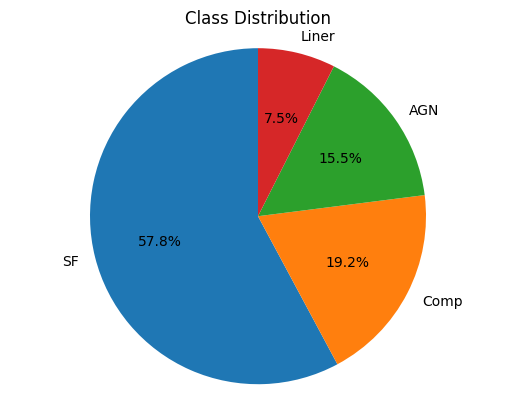

In [3]:
#plot class distribution in size order 

labels = ['SF', 'Comp', 'AGN', 'Liner']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Class Distribution')
plt.show()


In [4]:
#create a validation set from the training data
keras.backend.clear_session()
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

#apply standard scaler to the training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train_split = scaler.transform(X_train_split)

#apply standard scaler to the validation and training data
X_val_split = scaler.transform(X_val_split)
X_test = scaler.transform(X_test)

#dropout rate
p_dropout=0.5

#build the model
inputs = layers.Input(shape=(8,))

fc1 = layers.Dense(512, name="fc1", kernel_regularizer=keras.regularizers.l2(0.05))(inputs)
fc1 = layers.Activation(activation="relu")(fc1)
fc1 = layers.Dropout(p_dropout)(fc1)
fc1 = layers.BatchNormalization(axis=-1)(fc1)

fc2 = layers.Dense(512, name="fc2", kernel_regularizer=keras.regularizers.l2(0.05))(fc1)
fc2 = layers.Activation(activation="relu")(fc2)
fc2 = layers.Dropout(p_dropout)(fc2)
fc2 = layers.BatchNormalization(axis=-1)(fc2)

skip_connection = fc1  # skip connection

fc5 = layers.Dense(512, name="fc5", kernel_regularizer=keras.regularizers.l2(0.05))(fc2)
fc5 = layers.Activation(activation="relu")(fc5)
fc5 = layers.Dropout(p_dropout)(fc5)
fc5 = layers.BatchNormalization(axis=-1)(fc5)

combined_input = layers.Add()([fc5, skip_connection])
output = layers.Dense(4, activation='softmax')(combined_input)

model = models.Model(inputs=inputs, outputs=output)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 512)       │      4,608 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512)       │          0 │ fc1[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 512)       │    262,656 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512)       │          0 │ fc2[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc5 (Dense)         │ (None, 512)       │    262,656 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 512)       │          0 │ fc5[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dropout_2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │      2,052 │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 538,116 (2.05 MB)

 Trainable params: 535,044 (2.04 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [5]:
from tensorflow.keras.callbacks import LearningRateScheduler
import tensorflow as tf
from tensorflow.keras import backend as ops

#implement learning rate switch
def lr_schedule(epoch, lr):
    return 0.00001 if epoch >= 5 else 0.001

lr_callback = LearningRateScheduler(lr_schedule)

#compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

#train the model
model_history = model.fit(X_train_split, y_train_split, epochs=15, batch_size=16, verbose=1, shuffle=True, validation_data=(X_val_split, y_val_split),callbacks=[lr_callback])

Epoch 1/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.6194 - loss: 31.6450 - val_accuracy: 0.6951 - val_loss: 6.8860 - learning_rate: 0.0010
Epoch 2/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7709 - loss: 5.2860 - val_accuracy: 0.8142 - val_loss: 2.6170 - learning_rate: 0.0010
Epoch 3/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7986 - loss: 2.3616 - val_accuracy: 0.8262 - val_loss: 1.7061 - learning_rate: 0.0010
Epoch 4/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8055 - loss: 1.7182 - val_accuracy: 0.8404 - val_loss: 1.4459 - learning_rate: 0.0010
Epoch 5/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7976 - loss: 1.4770 - val_accuracy: 0.8273 - val_loss: 1.3114 - learning_rate: 0.0010
Epoch 6/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8234 - loss: 1.3374 - val_accuracy: 0.8404 - val_loss: 1.2584 - learning_rate: 1.0000e-05
Epoch 7/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7958 - lo

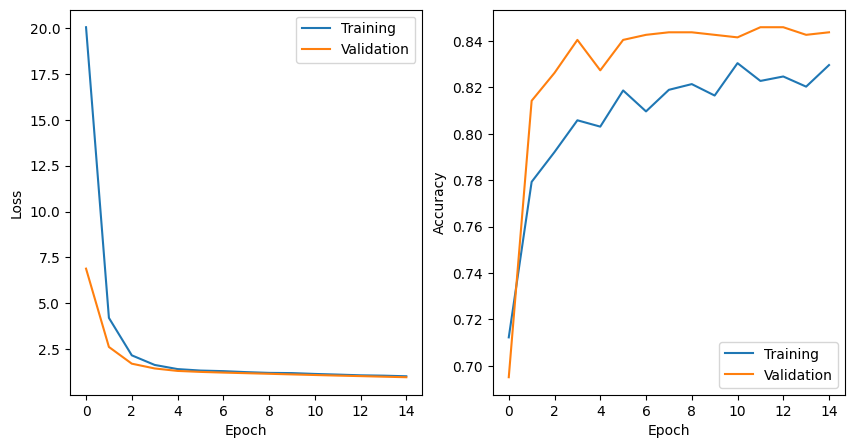

In [6]:
import sys
sys.path.append('..')
import plotting

#plot the model history (loss and accuracy)
plotting.plot_model_history(model_history)

In [7]:
#apply model to testing data
pred = model.predict(X_test,verbose=0)

#threshold adjustments to deal with unbalanced classes in our data
thresholds = {0: 0.7, 1: 0.3, 2: 0.25, 3: 0.3}  

y_pred_adjusted = np.argmax(pred, axis=1)

#apply thresholds to the predictions
for class_idx, threshold in thresholds.items():
    y_pred_adjusted[(pred[:, class_idx] > threshold) & (y_pred_adjusted != class_idx)] = class_idx



Overall accuracy:  0.8236493374108053


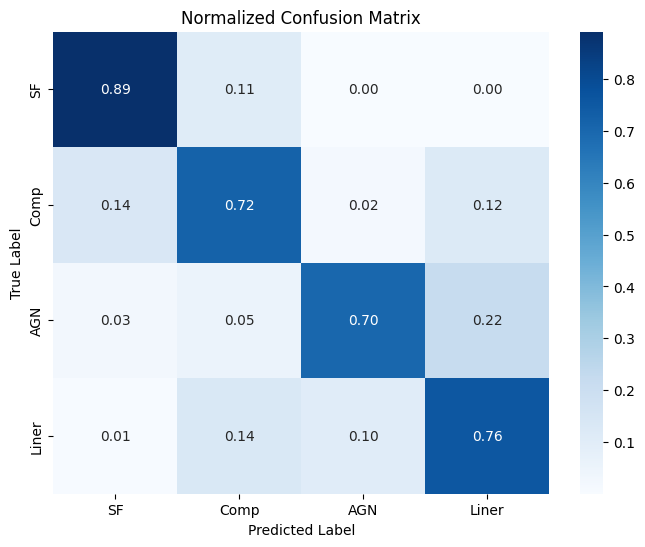

Accuracy for class SF: 0.8906 

Accuracy for class Comp: 0.7193 

Accuracy for class AGN: 0.6995 

Accuracy for class Liner: 0.7557 

              precision    recall  f1-score   support

          SF       0.94      0.89      0.92      1179
        Comp       0.66      0.72      0.69       424
         AGN       0.81      0.70      0.75       183
       Liner       0.59      0.76      0.66       176

    accuracy                           0.82      1962
   macro avg       0.75      0.77      0.75      1962
weighted avg       0.84      0.82      0.83      1962

Balanced Accuracy: 0.7662650586165439


In [8]:
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score


#calculate accuracy
from sklearn.metrics import accuracy_score
y_pred = np.argmax(pred, axis=1)
y_pred = y_pred_adjusted
y_true = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred)
print("Overall accuracy: ", accuracy)

#calculate confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

# normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# plot confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.savefig("../plots/NN-confusion_matrix.png")
plt.show()

for i, acc in enumerate(per_class_accuracy):
    print(f"Accuracy for class {labels[i]}: {acc:.4f} \n")

#calculate the full report on the model performance
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=labels))

#balanced accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print("Balanced Accuracy:", balanced_acc)

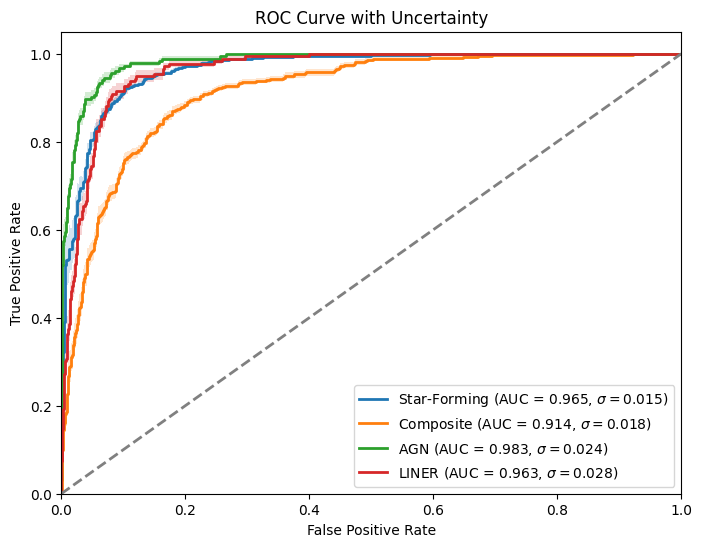

In [ ]:
#uncertainty calculation for our model
#using Monte Carlo Dropout to estimate uncertainty

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# function to perform Monte Carlo Dropout inference
def monte_carlo_predictions(model, X, num_samples=50):
    """
    Performs Monte Carlo Dropout inference to estimate model uncertainty.
    """
    preds = np.array([model(X, training=True).numpy() for _ in range(num_samples)])  
    return preds 

# number of MC samples
num_mc_samples = 50
mc_preds = monte_carlo_predictions(model, X_test, num_mc_samples)

# average out the results
y_pred_prob = np.mean(mc_preds[:, :, :4], axis=0)
y_pred_uncertainty = np.std(mc_preds[:, :, :4], axis=0) 

fpr = {}
tpr = {}
roc_auc = {}
tpr_uncertainty = {}

# calculate ROC curve and AUC for each class and plot it
for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    # interpolate TPR values to match the FPR grid
    tpr_samples = []
    for j in range(num_mc_samples):
        fpr_sample, tpr_sample, _ = roc_curve(y_test[:, i], mc_preds[j, :, i])
        
        interp_func = interp1d(fpr_sample, tpr_sample, kind='linear', fill_value='extrapolate')
        tpr_samples.append(interp_func(fpr[i]))

    tpr_samples = np.array(tpr_samples)
    tpr_uncertainty[i] = np.std(tpr_samples, axis=0) 

plt.figure(figsize=(8, 6))
classes = ['Star-Forming', 'Composite', 'AGN', 'LINER']

#for loop to check for NaN values and remove them if found
#the plotting is then done within the loop
for i in range(4):
    for n in tpr_uncertainty[i]:
        if np.isnan(n):
            tpr_uncertainty[i] = np.delete(tpr_uncertainty[i], np.where(np.isnan(tpr_uncertainty[i])))
            fpr[i] = np.delete(fpr[i], np.where(np.isnan(tpr_uncertainty[i])))
            tpr[i] = np.delete(tpr[i], np.where(np.isnan(tpr_uncertainty[i])))
            break
    plt.plot(fpr[i], tpr[i], lw=2, label=rf'{classes[i]} (AUC = {roc_auc[i]:.3f}, $\sigma = ${tpr_uncertainty[i].mean():.3f})')
    
    #find the minimum length of fpr and tpr arrays to avoid index errors
    min_len = min(len(tpr[i]), len(tpr_uncertainty[i])) 
    #plot the uncertainty
    plt.fill_between(
    fpr[i][:min_len], 
    tpr[i][:min_len] - tpr_uncertainty[i][:min_len],
    tpr[i][:min_len] + tpr_uncertainty[i][:min_len],  
    alpha=0.2)

#plotting details
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Uncertainty')
plt.legend(loc='lower right')
plt.savefig('../plots/NN-ROC_Curves.pdf', format='pdf')
plt.show()



In [10]:
#save the model within the directory
model.save('NN_model.keras')

# Intermediate Redshift Galaxies (0.32<z<0.8)

We now test our trained model on the intermediate redshift galaxy dataset to see how it performs.

In [11]:
#test the model on intermediate redshift
#open new data
file_path_features = '../data/X_extra_data.npy'
X_test = np.load(file_path_features)
file_path_labels = '../data/labels_extra_data.npy'
Y_test = np.load(file_path_labels)
Y_test = np.array(Y_test, dtype=int)

#standardize the data
scaler = StandardScaler()
X_test = scaler.fit_transform(X_test)

In [12]:
#load our model and get the weights
old_model = keras.models.load_model('NN_model.keras')
old_weights = old_model.get_weights()

p_dropout = 0.5

#define a new non-trainable model with the same architecture as the old one
#but import the weights

new_model = keras.Sequential()
inputs = layers.Input(shape=(8,))

fc1 = layers.Dense(512, name="fc1", kernel_regularizer=keras.regularizers.l2(0.01))(inputs)
fc1 = layers.Activation(activation="relu")(fc1)
fc1 = layers.Dropout(p_dropout)(fc1)
fc1 = layers.BatchNormalization(axis=-1)(fc1)

fc2 = layers.Dense(512, name="fc2", kernel_regularizer=keras.regularizers.l2(0.01))(fc1)
fc2 = layers.Activation(activation="relu")(fc2)
fc2 = layers.Dropout(p_dropout)(fc2)
fc2 = layers.BatchNormalization(axis=-1)(fc2)

skip_connection = fc1  

combined_input = layers.Add()([fc2, skip_connection])
fc5 = layers.Dense(512, name="fc5", kernel_regularizer=keras.regularizers.l2(0.01))(combined_input)
fc5 = layers.Activation(activation="relu")(fc5)
fc5 = layers.Dropout(p_dropout)(fc5)
fc5 = layers.BatchNormalization(axis=-1)(fc5)

output = layers.Dense(4, activation='softmax')(fc5)

new_model = models.Model(inputs=inputs, outputs=output)

#set all layers to not train
for layer in new_model.layers:
    layer.trainable = False 

new_weights = new_model.get_weights() 

# Transfer weights from old model to new model (manually skipping first layer)
for i in range(1, len(new_weights)):  
    new_weights[i] = old_weights[i]

# assign weights to new model
new_model.set_weights(new_weights)

new_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

new_model.summary(show_trainable=True)





Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 8)       │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ fc1 (Dense)       │ (None, 512)     │     4,608 │ input_layer_1… │   N   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ activation_3      │ (None, 512)     │         0 │ fc1[0][0]      │   -   │
│ (Activation)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_3         │ (None, 512)     │         0 │ activation_3[… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 512)     │     2,048 │ dropout_3[0][… │   N   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ fc2 (Dense)       │ (None, 512)     │   262,656 │ batch_normali… │   N   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ activation_4      │ (None, 512)     │         0 │ fc2[0][0]      │   -   │
│ (Activation)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_4         │ (None, 512)     │         0 │ activation_4[… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 512)     │     2,048 │ dropout_4[0][… │   N   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ add_1 (Add)       │ (None, 512)     │         0 │ batch_normali… │   -   │
│                   │                 │           │ batch_normali… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ fc5 (Dense)       │ (None, 512)     │   262,656 │ add_1[0][0]    │   N   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ activation_5      │ (None, 512)     │         0 │ fc5[0][0]      │   -   │
│ (Activation)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_5         │ (None, 512)     │         0 │ activation_5[… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 512)     │     2,048 │ dropout_5[0][… │   N   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 4)       │     2,052 │ batch_normali… │   N   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 538,116 (2.05 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 538,116 (2.05 MB)

0.4805194805194805


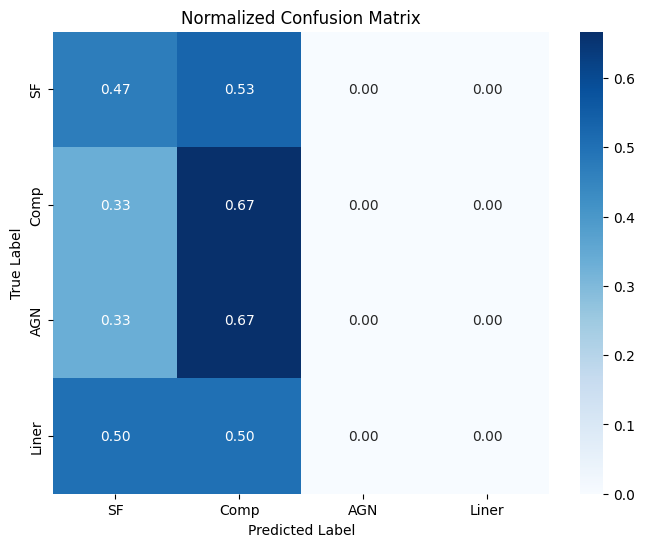

In [13]:
#predict test set
pred = new_model.predict(X_test,verbose=0)

thresholds = {0: 0.7, 1: 0.3, 2: 0.25, 3: 0.3} 

y_pred_adjusted = np.argmax(pred, axis=1)  # Default

for class_idx, threshold in thresholds.items():
    y_pred_adjusted[(pred[:, class_idx] > threshold) & (y_pred_adjusted != class_idx)] = class_idx


#calculate accuracy
from sklearn.metrics import accuracy_score
y_pred = y_pred_adjusted
y_true = np.argmax(Y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred)
print(accuracy)

#calculate confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
#print(cm)

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.savefig("../plots/NN-confusion_matrix.png")
plt.show()

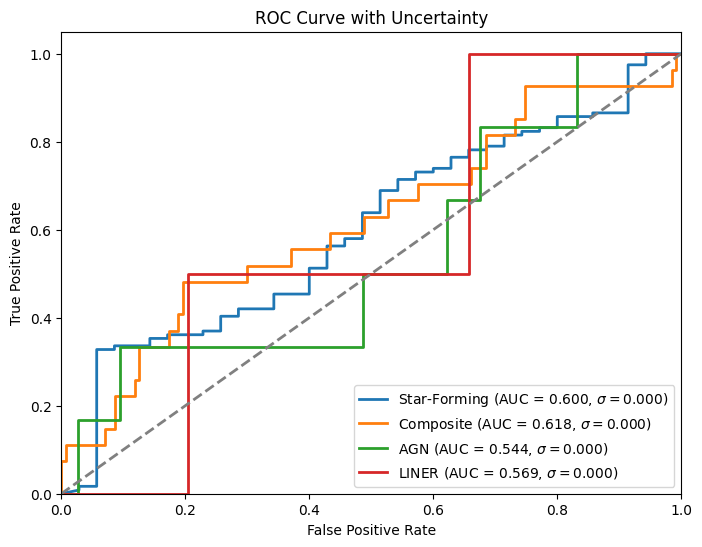

In [14]:
#calculate uncertainties, everything is the same as for our original model

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

fpr = {}
tpr = {}
roc_auc = {}
tpr_uncertainty = {}

def monte_carlo_predictions(model, X, num_samples=50):
    """
    Performs Monte Carlo Dropout inference to estimate model uncertainty.
    """
    preds = np.array([model(X, training=False).numpy() for _ in range(num_samples)])  
    return preds 

num_mc_samples = 50
mc_preds = monte_carlo_predictions(new_model, X_test, num_mc_samples)

y_pred_prob = np.mean(mc_preds[:, :, :4], axis=0)
y_pred_uncertainty = np.std(mc_preds[:, :, :4], axis=0) 

for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    tpr_samples = []
    for j in range(num_mc_samples):
        fpr_sample, tpr_sample, _ = roc_curve(Y_test[:, i], mc_preds[j, :, i])
        
        interp_func = interp1d(fpr_sample, tpr_sample, kind='linear', fill_value='extrapolate')
        tpr_samples.append(interp_func(fpr[i]))

    tpr_samples = np.array(tpr_samples)
    tpr_uncertainty[i] = np.std(tpr_samples, axis=0) 

plt.figure(figsize=(8, 6))
classes = ['Star-Forming', 'Composite', 'AGN', 'LINER']

for i in range(4):
    #check for nan values and remove them
    for n in tpr_uncertainty[i]:
        if np.isnan(n):
            tpr_uncertainty[i] = np.delete(tpr_uncertainty[i], np.where(np.isnan(tpr_uncertainty[i])))
            fpr[i] = np.delete(fpr[i], np.where(np.isnan(tpr_uncertainty[i])))
            tpr[i] = np.delete(tpr[i], np.where(np.isnan(tpr_uncertainty[i])))
            break
    plt.plot(fpr[i], tpr[i], lw=2, label=rf'{classes[i]} (AUC = {roc_auc[i]:.3f}, $\sigma = ${tpr_uncertainty[i].mean():.3f})')
    
    min_len = min(len(tpr[i]), len(tpr_uncertainty[i])) 
    plt.fill_between(
    fpr[i][:min_len], 
    tpr[i][:min_len] - tpr_uncertainty[i][:min_len],
    tpr[i][:min_len] + tpr_uncertainty[i][:min_len],  
    alpha=0.2)

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Uncertainty')
plt.legend(loc='lower right')
plt.savefig('../plots/INT-NN-ROC_Curves.pdf', format='pdf')
plt.show()